In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')

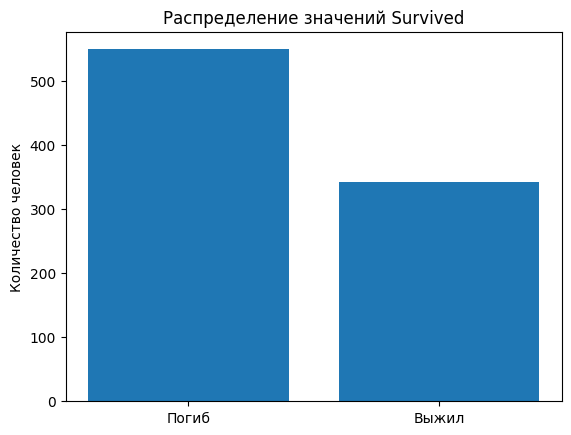

In [ ]:
counts = df['Survived'].value_counts().sort_index()
x = counts.index
y = counts.values
fig, ax = plt.subplots()
ax.bar(x=x, height=y)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Погиб', 'Выжил'])
ax.set_title('Распределение значений Survived')
ax.set_ylabel('Количество человек')
plt.show()

/tmp/ipykernel_520/1441803695.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


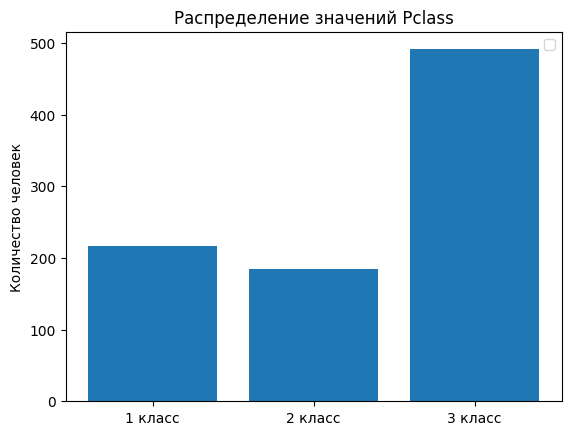

In [ ]:
counts = df['Pclass'].value_counts().sort_index()
x = counts.index
y = counts.values
fig, ax = plt.subplots()
ax.bar(x=x, height=y)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['1 класс', '2 класс', '3 класс'])
ax.set_title('Распределение значений Pclass')
ax.set_ylabel('Количество человек')
plt.show()

/tmp/ipykernel_520/2213682860.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


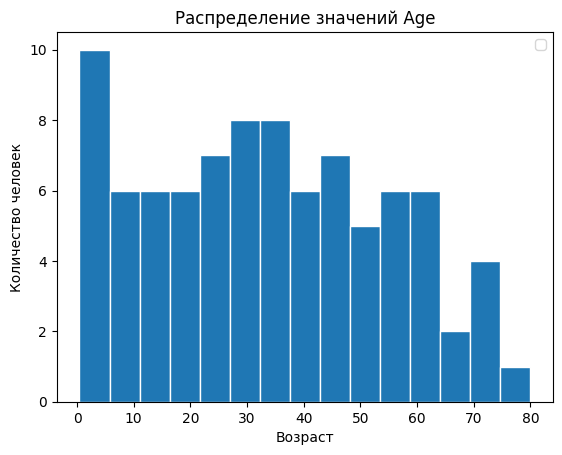

In [ ]:
counts = df['Age'].value_counts().sort_index()
x = counts.index
y = counts.values
fig, ax = plt.subplots()
ax.hist(x, bins=15, edgecolor='white')
ax.set_title('Распределение значений Age')
ax.set_xlabel('Возраст')
ax.set_ylabel('Количество человек')
plt.show()

/tmp/ipykernel_520/2201262569.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


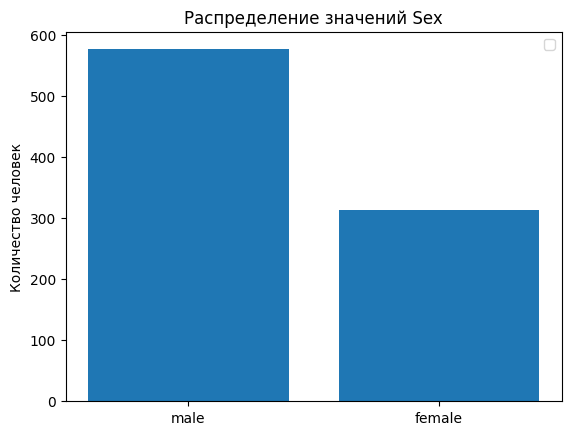

In [ ]:
counts = df['Sex'].value_counts()
x = counts.index
y = counts.values
fig, ax = plt.subplots()
ax.bar(x=x, height=y)
ax.set_title('Распределение значений Sex')
ax.set_ylabel('Количество человек')
plt.show()

/tmp/ipykernel_520/1766094924.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


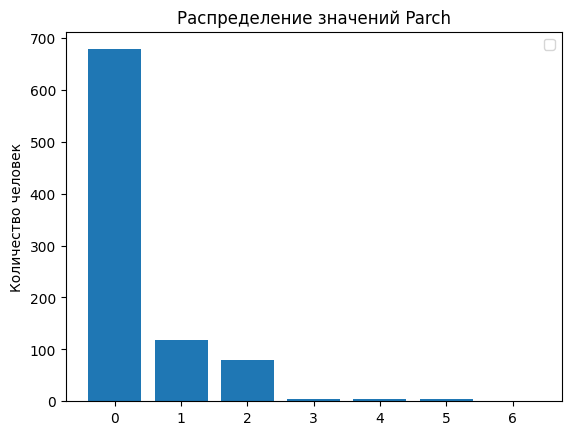

In [ ]:
counts = df['Parch'].value_counts().sort_index()
x = counts.index
y = counts.values
fig, ax = plt.subplots()
ax.bar(x=x, height=y)
ax.set_title('Распределение значений Parch')
ax.set_ylabel('Количество человек')
plt.show()

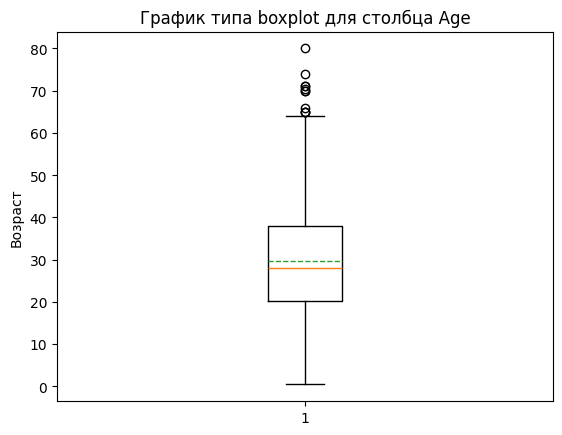

In [ ]:
x = df['Age'].dropna()
fig, ax = plt.subplots()
ax.boxplot(x, showmeans=True, meanline=True)
ax.set_title('График типа boxplot для столбца Age')
ax.set_ylabel('Возраст')
plt.show()

Интерпретация графика типа boxplot для столбца 'Age':
1) Медиана (основная жёлтая линия): показывает, где находится значение "среднего" возраста пассажиров в наборе данных. То есть 50% пассажиров моложе, 50% старше.
2) Среднее арифметическое (пунктирная зелёная линия) – сумма всех возрастов, делённая на их количество.
3) Ящик (IQR): Края ящика соответствуют 25-му и 75-му перцентилям. Это означает, что 50% всех пассажиров имеют возраст в этом диапазоне (значения сосредоточены внутри этого ящика). Также, до нижней границы сосредоточено 25% значений возраста пассажиров, и после верхней границы тоже 25%.
4) Усы: показывают границы нормального разброса возрастов, которые не считаются выбросами. Это высчитанное значение для минимума: Q1-1.5IQR, где IQR - ширина ящика, Q1 - нижняя граница ящика; а для максимума: Q3+1.5IQR, где IQR - ширина ящика, Q3 - верхняя граница ящика.
5) Выбросы: это отдельные точки за пределами усов, которые показывают пассажиров, возраст которых значительно отличается от большинства.

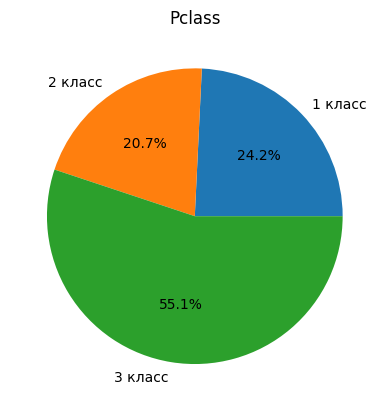

In [ ]:
labels = ['1 класс', '2 класс', '3 класс']
value = df['Pclass'].value_counts().sort_index()
fig, ax = plt.subplots()
ax.pie(value, labels=labels, autopct='%1.1f%%')
ax.set_title('Pclass')
plt.show()

In [ ]:
labels = ['Погиб', 'Выжил']
value = df['Survived'].value_counts()
fig, ax = plt.subplots()
ax.pie(value, labels=labels, autopct='%1.1f%%')
ax.set_title('Survived')
plt.show()

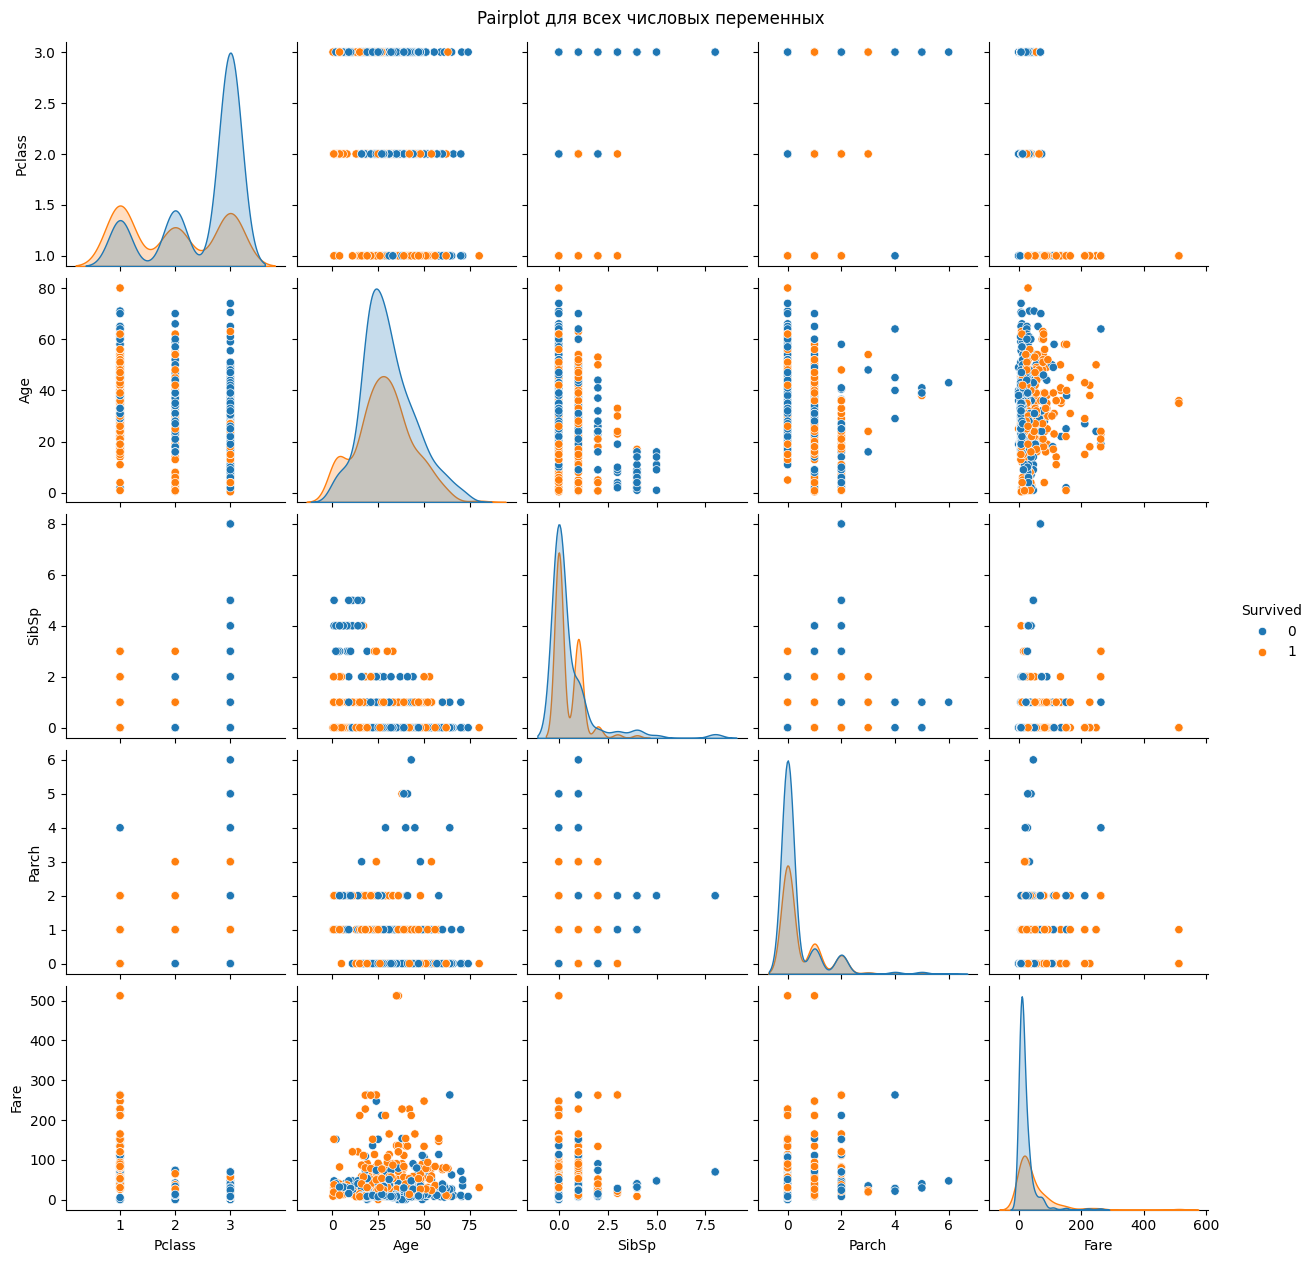

In [12]:
x = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
x.remove('PassengerId')
sns.pairplot(df[x], hue='Survived')
plt.suptitle('Pairplot для всех числовых переменных', y = 1.01)
plt.show()

In [14]:
import plotly.express as px
data = df.groupby(['Pclass', 'Sex']).size().reset_index(name='count')
fig = px.sunburst(data, path=['Pclass', 'Sex'], values='count', title='Распределение пассажиров по классу и полу')
fig.show()